In [1]:
import random

import numpy as np
import torch


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

In [3]:
import pandas as pd


train_path = "../data/KDDTrain+.txt"
test_path = "../data/KDDTest+.txt"

train_df = pd.read_csv(train_path, names=columns)
test_df = pd.read_csv(test_path, names=columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
print(train_df.info())
print("\nMissing values in train:", train_df.isnull().sum().sum())
print("Missing values in test:", test_df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [5]:
train_df["binary_label"] = train_df["label"].apply(lambda x: 0 if x == "normal" else 1)
test_df["binary_label"] = test_df["label"].apply(lambda x: 0 if x == "normal" else 1)

print(train_df["binary_label"].value_counts())
print(test_df["binary_label"].value_counts())

binary_label
0    67343
1    58630
Name: count, dtype: int64
binary_label
1    12833
0     9711
Name: count, dtype: int64


In [6]:
dos_attacks = ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop', 'mailbomb',
               'apache2', 'processtable', 'udpstorm']
probe_attacks = ['ipsweep', 'nmap', 'portsweep', 'satan', 'mscan', 'saint']
r2l_attacks = ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy',
               'warezclient', 'warezmaster', 'sendmail', 'named', 'snmpgetattack',
               'snmpguess', 'xlock', 'xsnoop', 'worm']
u2r_attacks = ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'httptunnel',
               'ps', 'sqlattack', 'xterm']

def attack_category(label):
    if label == "normal":
        return "normal"
    elif label in dos_attacks:
        return "dos"
    elif label in probe_attacks:
        return "probe"
    elif label in r2l_attacks:
        return "r2l"
    elif label in u2r_attacks:
        return "u2r"
    else:
        return "other"

train_df["attack_category"] = train_df["label"].apply(attack_category)
test_df["attack_category"] = test_df["label"].apply(attack_category)

train_df["attack_category"].value_counts()

attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

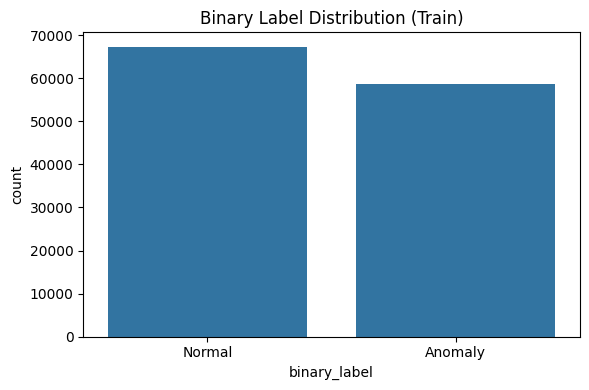

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# EDA: binary label distribution
plt.figure(figsize=(6,4))
sns.countplot(x="binary_label", data=train_df)
plt.title("Binary Label Distribution (Train)")
plt.xticks([0,1], ["Normal", "Anomaly"])
plt.tight_layout()
plt.savefig("../results/figures/binary_distribution_train.png")
plt.show()

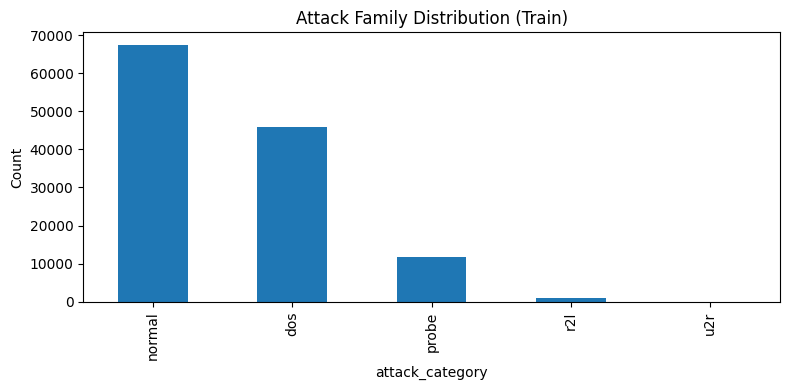

In [8]:
# EDA: attack family distribution
plt.figure(figsize=(8,4))
train_df["attack_category"].value_counts().plot(kind="bar")
plt.title("Attack Family Distribution (Train)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../results/figures/attack_family_distribution.png")
plt.show()

In [9]:
train_df.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.0,0.0,0.0,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.0,44.0,276.0,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.0,0.0,516.0,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.0,0.0,0.0,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.0,0.0,0.0,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.0,0.0,0.0,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.0,0.0,0.0,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.0,0.0,0.0,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.0,0.0,1.0,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.0,0.0,0.0,7.479000e+03


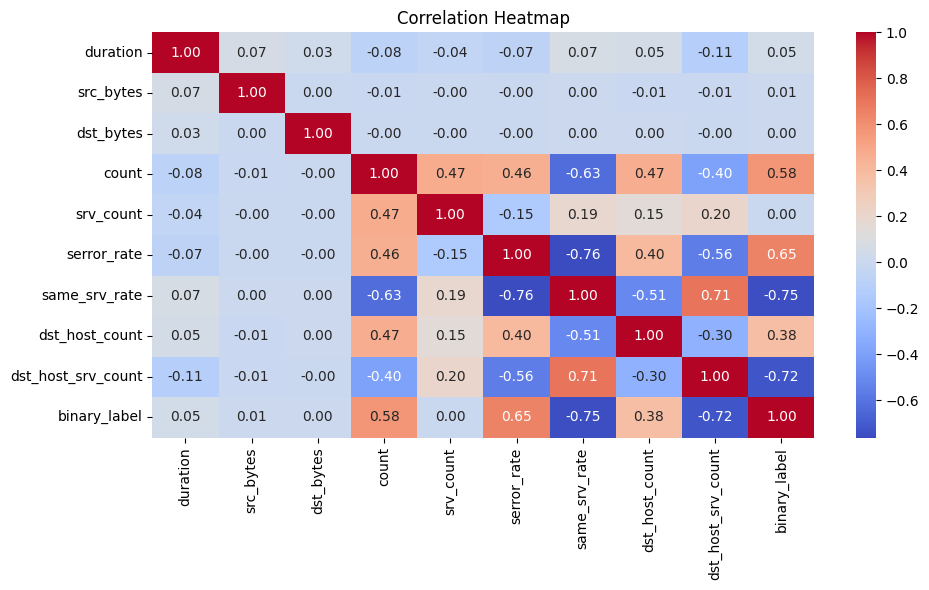

In [ ]:
# EDA: correlation heatmap for selected numerical features
selected_cols = [
    "duration", "src_bytes", "dst_bytes", "count", "srv_count",
    "serror_rate", "same_srv_rate", "dst_host_count", "dst_host_srv_count",
    "binary_label"
]

plt.figure(figsize=(10,6))
sns.heatmap(train_df[selected_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../results/figures/correlation_heatmap.png")
plt.show()

In [11]:
# Feature selection
categorical_cols = ["protocol_type", "service", "flag"]
drop_cols = ["label", "difficulty", "attack_category", "binary_label"]

feature_cols = [c for c in train_df.columns if c not in drop_cols]
numerical_cols = [c for c in feature_cols if c not in categorical_cols]

print("Total features:", len(feature_cols))
print("Categorical:", categorical_cols)
print("Numerical count:", len(numerical_cols))

Total features: 41
Categorical: ['protocol_type', 'service', 'flag']
Numerical count: 38
